# Assignment 1: Web Scraping & Data Analysis

**Student:** Yang Hong (2255396)  
**Date:** Oct 27, 2025  
**Dataset:** [TV Maze](https://www.tvmaze.com/shows)

### ⚙️ Environment Setup

Before running the crawler and visualization modules, ensure your environment has the required dependencies installed.

In [1]:
# !pip install requests urllib3 beautifulsoup4 pandas numpy matplotlib seaborn tqdm

## Task 1 — Web Scraping (200 Titles)
This section scrapes TV Maze to collect **200** titles with the required 8 fields and saves them to `YangHong2255396.csv`.

In [2]:
#Tool functions and drawing functions

import json
import logging
import os
import random
import re
import sys
import threading
import time
from dataclasses import dataclass
from typing import Any, Optional

import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


@dataclass(frozen=True)
class Config:
    """Global config (HTML fetching only)"""
    TIMEOUT: int = 15
    SLEEP_AFTER_REQ: float = 0.10   # base sleep (plus jitter)
    MAX_RETRY: int = 3              # urllib3-level idempotent retries
    BACKOFF: float = 0.3            # urllib3 exponential backoff factor
    SUMMARY_MAX_LEN: int = 280
    MAX_WORKERS: int = 4            # thread pool; 3–4 is reasonable
    MIN_INTERVAL: float = 0.8       # global minimum inter-request interval (sec)
    JITTER_MAX: float = 0.4         # extra jitter (sec)
    PER_HOST_CONCURRENCY: int = 2   # same-host concurrency cap (semaphore)
    RATE_LIMIT_BACKOFF: float = 2.0 # base backoff for HTTP 429 (sec)
    MAX_RATE_LIMIT_SLEEP: float = 60.0  # max wait time on 429 (sec)

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:123.0) Gecko/20100101 Firefox/123.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 14_0) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 Safari/605.1.15",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36 Edg/120.0.0.0",
]
_PER_HOST_LOCK = threading.Semaphore(Config.PER_HOST_CONCURRENCY)
_LAST_REQUEST_TS = 0.0
_RATE_LOCK = threading.Lock()


def setup_logging(log_file: Optional[str] = None) -> None:
    handlers: list[logging.Handler] = [logging.StreamHandler(sys.stdout)]
    if log_file:
        os.makedirs(os.path.dirname(log_file), exist_ok=True)
        handlers.append(logging.FileHandler(log_file, encoding="utf-8"))
    logging.basicConfig(
        format="[%(asctime)s] %(levelname)s - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        handlers=handlers
    )


def get_session() -> requests.Session:
    sess = requests.Session()

    retry = Retry(
        total=Config.MAX_RETRY,
        read=Config.MAX_RETRY,
        connect=Config.MAX_RETRY,
        backoff_factor=Config.BACKOFF,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=50, pool_maxsize=50)
    sess.mount("http://", adapter)
    sess.mount("https://", adapter)

    ua = random.choice(USER_AGENTS)
    sess.headers.update({
        "User-Agent": ua,
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
        "Connection": "keep-alive",
        "Upgrade-Insecure-Requests": "1",
        # requests handles gzip/deflate/br automatically
        "Sec-Fetch-Site": "same-origin",
        "Sec-Fetch-Mode": "navigate",
    })
    return sess


def polite_sleep(min_interval: float | None = None, jitter: float | None = None) -> None:
    global _LAST_REQUEST_TS
    if min_interval is None:
        min_interval = Config.MIN_INTERVAL
    if jitter is None:
        jitter = Config.JITTER_MAX

    with _RATE_LOCK:
        now = time.time()
        wait = _LAST_REQUEST_TS + min_interval - now
        if wait > 0:
            time.sleep(wait)
        time.sleep(random.uniform(0, jitter))
        _LAST_REQUEST_TS = time.time()


def get_html(
    sess: requests.Session,
    url: str,
    referer: Optional[str] = None,
    *,
    max_attempts: int = 6,
    base_sleep: float = 1.0,
) -> Optional[str]:
    """Fetch HTML with retries and error handling."""
    attempt = 0
    consecutive_429 = 0
    
    while attempt < max_attempts:
        attempt += 1
        polite_sleep()  # throttle
        
        with _PER_HOST_LOCK:
            try:
                headers = {}
                if referer:
                    headers["Referer"] = referer
                resp = sess.get(url, timeout=Config.TIMEOUT, headers=headers)
            except requests.Timeout as e:
                logging.warning(f"[GET] timeout on {url} (attempt {attempt}/{max_attempts}): {e}")
                time.sleep(base_sleep * (2 ** (attempt - 1)) + random.uniform(0.3, 0.8))
                continue
            except requests.ConnectionError as e:
                logging.warning(f"[GET] connection error on {url} (attempt {attempt}/{max_attempts}): {e}")
                time.sleep(base_sleep * (2 ** (attempt - 1)) + random.uniform(0.5, 1.0))
                continue
            except requests.RequestException as e:
                logging.warning(f"[GET] request exception on {url} (attempt {attempt}/{max_attempts}): {e}")
                time.sleep(base_sleep * (2 ** (attempt - 1)) + random.uniform(0.2, 0.6))
                continue

        ct = resp.headers.get("Content-Type", "")
        
        if resp.status_code == 200 and ("text/html" in ct or ct.startswith("text/")):
            time.sleep(Config.SLEEP_AFTER_REQ + random.uniform(0, 0.05))
            consecutive_429 = 0
            return resp.text

        # Handle 429
        if resp.status_code == 429:
            consecutive_429 += 1
            ra = resp.headers.get("Retry-After")
            
            if ra:
                try:
                    sleep_s = float(ra)
                    sleep_s = min(sleep_s, Config.MAX_RATE_LIMIT_SLEEP)
                except ValueError:
                    sleep_s = Config.RATE_LIMIT_BACKOFF * (2 ** (consecutive_429 - 1))
                    sleep_s = min(sleep_s, Config.MAX_RATE_LIMIT_SLEEP)
            else:
                sleep_s = Config.RATE_LIMIT_BACKOFF * (2 ** (consecutive_429 - 1))
                sleep_s = min(sleep_s, Config.MAX_RATE_LIMIT_SLEEP)
            
            jitter = random.uniform(0.5, 1.5)
            total_sleep = sleep_s * jitter
            
            logging.warning(f"[429] {url} -> sleep {total_sleep:.2f}s (attempt {attempt}/{max_attempts})")
            time.sleep(total_sleep)
            continue

        # Server errors
        if 500 <= resp.status_code < 600:
            sleep_s = base_sleep * (2 ** (attempt - 1))
            jitter = random.uniform(0.3, 0.9)
            total_sleep = sleep_s + jitter
            logging.warning(f"[{resp.status_code}] {url} -> backoff {total_sleep:.2f}s")
            time.sleep(total_sleep)
            continue

        # Auth/forbidden
        if resp.status_code in (403, 401):
            sleep_s = base_sleep * (2 ** (attempt - 1)) + 1.0
            jitter = random.uniform(0.5, 1.5)
            total_sleep = sleep_s + jitter
            logging.warning(f"[{resp.status_code}] {url} -> throttling {total_sleep:.2f}s")
            time.sleep(total_sleep)
            continue

        if resp.status_code != 200:
            logging.warning(f"[GET] HTTP {resp.status_code} on {url}")
            if attempt < max_attempts:
                time.sleep(base_sleep + random.uniform(0.2, 0.6))
                continue
        
        return None

    logging.error(f"[GET] failed after {max_attempts} attempts: {url}")
    return None


_TAG_RE = re.compile(r"<[^>]+>")


def strip_html(text: Optional[str]) -> str:
    if not text:
        return ""
    clean = _TAG_RE.sub("", text)
    return re.sub(r"\s+", " ", clean).strip()


def truncate(text: str, max_len: int = Config.SUMMARY_MAX_LEN) -> str:
    if len(text) <= max_len:
        return text
    return text[:max_len - 1].rstrip() + "…"


def normalize_date(date_str: Optional[str]) -> str:
    return date_str.replace("-", "/") if date_str else ""


def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def save_csv(df: pd.DataFrame, path: str) -> None:
    ensure_dir(os.path.dirname(path) or ".")
    df.to_csv(path, index=False, encoding="utf-8-sig")


def read_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path)


def format_genres(genres: list[str]) -> str:
    try:
        return json.dumps(genres, ensure_ascii=False)
    except Exception:
        return "[]"

import json
import os
import re
from datetime import date, datetime
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ----------------------------- I/O utils -----------------------------
def read_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path)


def ensure_dir(d: str) -> None:
    os.makedirs(d, exist_ok=True)


# ----------------------------- Matplotlib config -----------------------------
def configure_matplotlib() -> None:
    plt.style.use("default")
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.08,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.labelweight": "normal",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.grid": False,
        "lines.linewidth": 1.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica", "SimHei"] + plt.rcParams.get("font.sans-serif", [])
    plt.rcParams["axes.unicode_minus"] = False


# ----------------------------- Dictionaries -----------------------------
BROADCAST = [
    "abc", "cbs", "nbc", "fox", "the cw", "pbs",
    "bbc one", "bbc two", "bbc three", "bbc four", "itv", "channel 4", "channel 5",
]
CABLE_PREMIUM = [
    "hbo", "showtime", "starz", "amc", "fx", "fxx", "usa network", "syfy", "tnt", "tbs",
    "a&e", "history", "bravo", "comedy central", "mtv", "vh1", "e!", "hallmark", "freeform",
    "nickelodeon", "cartoon network", "adult swim", "discovery channel", "national geographic",
    "nat geo", "hgtv", "food network", "bbc america", "sky one", "sky atlantic", "tv land",
]
STREAMERS = [
    "netflix", "amazon", "prime video", "hulu", "disney+", "apple tv+", "paramount+", "peacock", "max",
    "discovery+", "amc+", "crave", "stan", "itvx", "bbc iplayer", "hotstar", "jiocinema", "viu",
    "iqiyi", "tencent", "youku",
]


# ----------------------------- Helpers -----------------------------
def _parse_date(s: Optional[str]) -> Optional[datetime]:
    if not isinstance(s, str) or not s.strip():
        return None
    try:
        return datetime.strptime(s.strip(), "%Y-%m-%d")
    except Exception:
        return None


def _year_from_date_str(s: Optional[str]) -> Optional[int]:
    dt = _parse_date(s)
    return dt.year if dt else None


def _status_group(raw: Optional[str]) -> str:
    if not isinstance(raw, str):
        return "Other"
    s = raw.strip().lower()
    if "ended" in s:
        return "Ended"
    if any(k in s for k in ["running", "continuing", "returning", "on hiatus", "in production"]):
        return "Running"
    if any(k in s for k in ["to be determined", "tbd", "unknown", "pending"]):
        return "To Be Determined"
    return "Other"


def _platform_type_from_network(net: Optional[str]) -> str:
    if not isinstance(net, str) or not net.strip():
        return "Other"
    s = net.strip().lower()
    if any(k in s for k in STREAMERS):
        return "Streamer"
    if any(k in s for k in BROADCAST):
        return "Broadcast"
    if any(k in s for k in CABLE_PREMIUM):
        return "Cable/Premium"
    return "Other"


def _parse_genres(cell: Optional[str]) -> List[str]:
    if not isinstance(cell, str) or not cell.strip():
        return []
    c = cell.strip()
    if c.startswith("[") and c.endswith("]"):
        try:
            arr = json.loads(c)
            return [str(x).strip() for x in arr if str(x).strip()]
        except Exception:
            pass
    return [x.strip() for x in c.split(",") if x.strip()]


def _freedman_diaconis_bins(vals: np.ndarray, max_bins: int = 50) -> int:
    v = np.asarray(vals, dtype=float)
    v = v[np.isfinite(v)]
    if v.size < 2:
        return 10
    q75, q25 = np.percentile(v, [75, 25])
    iqr = max(q75 - q25, 1e-9)
    bw = 2 * iqr * (v.size ** (-1/3))
    if bw <= 0:
        return min(20, len(np.unique(v)))
    bins = int(np.ceil((v.max() - v.min()) / bw))
    return max(5, min(bins, max_bins))


def _bootstrap_ci_mean(vals: np.ndarray, n_boot: int = 3000, alpha: float = 0.05, seed: int = 42) -> Tuple[float, float, float]:
    v = np.asarray(vals, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    n = v.size
    boots = rng.choice(v, size=(n_boot, n), replace=True).mean(axis=1)
    mean = float(v.mean())
    low = float(np.quantile(boots, alpha / 2))
    high = float(np.quantile(boots, 1 - alpha / 2))
    return mean, low, high


# ----------------------------- Derivations -----------------------------
def derive_variables(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    for c in ["Title", "First air date", "End date", "Rating", "Genres", "Status", "Network", "Summary"]:
        if c not in d.columns:
            d[c] = np.nan

    d["Rating"] = pd.to_numeric(d["Rating"], errors="coerce")
    d["End date"] = d["End date"].replace({"9999-12-31": np.nan, "9999/12/31": np.nan})

    d["StatusGroup"] = d["Status"].apply(_status_group)
    d["YearFirst"] = d["First air date"].apply(_year_from_date_str)
    d["YearEnd"] = d["End date"].apply(_year_from_date_str)

    def _years_active(row) -> Optional[float]:
        fst = _parse_date(row.get("First air date"))
        if not fst:
            return np.nan
        end_dt = _parse_date(row.get("End date"))
        if end_dt is None and row.get("StatusGroup") != "Ended":
            end_dt = datetime.combine(date.today(), datetime.min.time())
        if end_dt is None:
            return np.nan
        return max(0.0, (end_dt - fst).days / 365.25)

    d["YearsActive"] = d.apply(_years_active, axis=1)
    d["PlatformType"] = d["Network"].apply(_platform_type_from_network)
    d["NumGenres"] = d["Genres"].apply(lambda x: len(_parse_genres(x)))
    return d


# ----------------------------- Figures -----------------------------
def fig_rating_hist(d: pd.DataFrame, out_path: str) -> None:
    vals = d["Rating"].dropna().values
    if vals.size == 0:
        return
    bins = _freedman_diaconis_bins(vals)
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.hist(vals, bins=bins, alpha=0.85, edgecolor="#222222", linewidth=0.8)
    mean, median = vals.mean(), np.median(vals)
    ax.axvline(mean, linestyle="--", linewidth=1.8, label=f"Mean {mean:.2f}")
    ax.axvline(median, linestyle="-.", linewidth=1.6, label=f"Median {median:.2f}")
    ax.set_xlabel("Rating (0–10)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of Ratings")
    ax.legend(loc="upper left", frameon=False)
    fig.savefig(out_path)
    plt.close(fig)


def fig_avg_rating_by_genre(
    d: pd.DataFrame,
    out_path: str,
    top_n: int = 12,
    min_n: int = 5,
    show_counts: str = "none",   # "xtick" | "above" | "none"
    sort_by: str = "mean",        # "mean" | "freq"
    save_svg: bool = True,
) -> None:
    plt.rcParams.update({
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "grid.color": "#808080",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
        "grid.alpha": 0.35,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    })

    dd = d.copy()
    dd["__genres"] = dd["Genres"].apply(_parse_genres)
    dd = dd.explode("__genres").rename(columns={"__genres": "Genre"}).dropna(subset=["Genre"])
    if dd.empty:
        return

    freq = dd["Genre"].value_counts()
    cand = freq.head(top_n).index.tolist()

    rows = []
    for g in cand:
        x = dd.loc[dd["Genre"] == g, "Rating"].dropna().values
        if x.size >= min_n:
            m, lo, hi = _bootstrap_ci_mean(x)
            rows.append((g, m, lo, hi, x.size))
    if not rows:
        return

    tbl = pd.DataFrame(rows, columns=["Genre", "Mean", "Low", "High", "n"])
    if sort_by == "freq":
        tbl = tbl.sort_values("n", ascending=False)
    else:
        tbl = tbl.sort_values("Mean", ascending=False).reset_index(drop=True)

    def _palette(n, cmap_name="tab20"):
        cmap = plt.get_cmap(cmap_name)
        return [cmap(i) for i in np.linspace(0.05, 0.95, n)]
    colors = _palette(len(tbl))

    fig_w = max(7.6, 0.55 * len(tbl) + 3.2)
    fig, ax = plt.subplots(figsize=(fig_w, 4.8))

    x = np.arange(len(tbl))
    bar_kwargs = dict(width=0.7, edgecolor="#222222", linewidth=0.8, alpha=0.95)
    for i, (m, c) in enumerate(zip(tbl["Mean"].values, colors)):
        ax.bar(i, m, color=c, **bar_kwargs)

    y = tbl["Mean"].values
    yerr = np.vstack([y - tbl["Low"].values, tbl["High"].values - y])
    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="#222222", elinewidth=1.0, capsize=3, zorder=3)
    if show_counts == "xtick":
        xticklabels = [f"{g}\n(n={n})" for g, n in zip(tbl["Genre"], tbl["n"])]
    else:
        xticklabels = tbl["Genre"].tolist()
    ax.set_xticks(x, labels=xticklabels, rotation=28, ha="right")
    if show_counts == "above":
        for i, (m, n) in enumerate(zip(tbl["Mean"].values, tbl["n"].values)):
            ax.text(i, m + (0.015 * (tbl["High"].max() - tbl["Low"].min())), f"n={n}",
                    ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Average Rating")
    ax.set_title("Average Rating by Genre (Top by frequency)")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    y_min = max(0, (tbl["Low"].min() - 0.1))
    y_max = min(10, (tbl["High"].max() + 0.1)) if np.isfinite(tbl["High"].max()) else tbl["High"].max()
    if np.isfinite(y_min) and np.isfinite(y_max) and (y_max > y_min):
        ax.set_ylim(y_min, y_max)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight", format="png")
    plt.close(fig)


def fig_box_rating_by_status(d: pd.DataFrame, out_path: str) -> None:
    required = {"StatusGroup", "Rating"}
    if not required.issubset(d.columns):
        return
    df = d.dropna(subset=["Rating"]).copy()
    if df.empty:
        return

    def _normalize_status(x: str) -> str:
        s = str(x).strip().lower()
        if re.match(r"^\s*running\b", s):
            return "Running"
        if re.search(r"\b(ended|complete|completed|finished|closed)\b", s):
            return "Ended"
        if re.search(r"\b(to\s*be\s*determined|tbd|tba|pending|unknown)\b", s):
            return "To Be Determined"
        if s in {"ended", "running", "other"}:
            return s.title()
        if s == "to be determined":
            return "To Be Determined"
        return "Other"

    df["StatusGroupClean"] = df["StatusGroup"].map(_normalize_status)
    labels = [g for g in ("Ended", "Running", "To Be Determined", "Other") if g in df["StatusGroupClean"].unique()]

    plt.rcParams.update({
        "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
        "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "axes.linewidth": 0.8, "axes.labelsize": 9, "axes.titlesize": 10,
        "xtick.labelsize": 8, "ytick.labelsize": 8, "axes.grid": False,
    })

    fig, ax = plt.subplots(figsize=(6.0, 3.8), dpi=150)
    sns.boxplot(
        data=df,
        x="StatusGroupClean",
        y="Rating",
        hue="StatusGroupClean",
        order=labels,
        palette="deep",
        showmeans=True,
        notch=True,
        linewidth=1.5,
        ax=ax,
        legend=False
    )
    ax.set_title("Ratings by StatusGroup", fontsize=10, loc="left", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Rating", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    fig.savefig(out_path)
    plt.close(fig)


def fig_scatter_yearsactive_vs_rating(d: pd.DataFrame, out_path: str) -> None:
    dd = d.dropna(subset=["YearsActive", "Rating"]).copy()
    if dd.empty:
        return
    x, y = dd["YearsActive"].values, dd["Rating"].values

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, s=10, alpha=0.5, edgecolor="none", c="blue", label="Data points")

    if x.size >= 2:
        k, b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 200)
        ax.plot(xx, k * xx + b, linewidth=2, linestyle="--", color="red", label=f"Fit: y={k:.2f}x + {b:.2f}")
        y_pred = k * x + b
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2) if x.size > 1 else np.nan
        r2 = 1 - ss_res / ss_tot if ss_tot and np.isfinite(ss_tot) else np.nan
        ax.legend(loc="lower left", frameon=False, title=f"R² = {r2:.3f}")

    ax.set_xlabel("Years Active (years)")
    ax.set_ylabel("Rating")
    ax.set_title("Years Active vs Rating (with linear fit)")
    fig.tight_layout()
    fig.savefig(out_path)
    plt.close(fig)


def fig_avg_rating_by_network_top10(d: pd.DataFrame, out_path: str, top_n_by_count: int = 10, min_n: int = 5) -> None:
    dd = d.copy()
    dd["Network"] = dd["Network"].fillna("").replace("", "Unknown")
    counts = dd["Network"].value_counts()
    cand = counts.head(top_n_by_count).index.tolist()

    rows = []
    for net in cand:
        x = dd.loc[dd["Network"] == net, "Rating"].dropna().values
        if x.size >= min_n:
            m, lo, hi = _bootstrap_ci_mean(x)
            rows.append((net, m, lo, hi))
    if not rows:
        return

    tbl = pd.DataFrame(rows, columns=["Network", "Mean", "Low", "High"]).sort_values("Mean", ascending=True)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    y = np.arange(len(tbl))
    colors = plt.cm.Blues(np.linspace(0.45, 0.85, len(tbl)))

    ax.barh(y, tbl["Mean"], color=colors, edgecolor="none", height=0.6)
    xerr = np.vstack([tbl["Mean"] - tbl["Low"], tbl["High"] - tbl["Mean"]])
    ax.errorbar(tbl["Mean"], y, xerr=xerr, fmt="none", ecolor="#333333", elinewidth=1.0, capsize=3)

    ax.set_yticks(y, labels=tbl["Network"])
    ax.set_xlabel("Average Rating")
    ax.set_title("Average Rating by Network (Top 10 by representation)", fontsize=12, weight="bold", pad=10)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="x", linestyle="--", linewidth=0.5, color="gray", alpha=0.4)
    ax.yaxis.grid(False)

    fig.tight_layout()
    fig.savefig(out_path)
    plt.close(fig)


def fig_platform_type_share(d: pd.DataFrame, out_path: str) -> None:
    cnt = d["PlatformType"].value_counts()
    if cnt.empty:
        return
    share = (cnt / cnt.sum() * 100).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    y = np.arange(len(share))
    ax.barh(y, share.values, height=0.7, edgecolor="#222222", linewidth=0.8, alpha=0.9)
    ax.set_yticks(y, labels=share.index.tolist())
    ax.set_xlim(0, max(share.values.max() * 1.15, 10))
    for i, v in enumerate(share.values):
        ax.text(v + max(share.values) * 0.01, i, f"{v:.1f}%", va="center", ha="left", fontsize=9)
    ax.set_xlabel("Share of Shows (%)")
    ax.set_title("PlatformType Share (Streamer/Broadcast/Cable-Premium/Other)")
    fig.savefig(out_path)
    plt.close(fig)


def fig_new_shows_by_year(d: pd.DataFrame, out_path: str) -> None:
    s = d["YearFirst"].dropna().astype(int).value_counts().sort_index()
    if s.empty:
        return
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.bar(s.index.values, s.values, width=0.85, edgecolor="#222222", linewidth=0.6, alpha=0.9)
    ax.set_xlabel("YearFirst")
    ax.set_ylabel("Number of New Shows")
    ax.set_title("New Shows by Year (YearFirst)")
    fig.savefig(out_path)
    plt.close(fig)


def Visualization(csv_path: str, out_dir: str = "figures") -> None:
    configure_matplotlib()
    ensure_dir(out_dir)

    df = read_csv(csv_path)
    df = derive_variables(df)

    fig_rating_hist(df, os.path.join(out_dir, "fig_rating_hist.png"))
    fig_avg_rating_by_genre(df, os.path.join(out_dir, "fig_avg_rating_by_genre.png"), top_n=12, min_n=5)
    fig_box_rating_by_status(df, os.path.join(out_dir, "fig_box_rating_by_status.png"))
    fig_scatter_yearsactive_vs_rating(df, os.path.join(out_dir, "fig_scatter_yearsactive_vs_rating.png"))
    fig_avg_rating_by_network_top10(df, os.path.join(out_dir, "fig_avg_rating_by_network_top10.png"), top_n_by_count=10, min_n=5)
    fig_platform_type_share(df, os.path.join(out_dir, "fig_platform_type_share.png"))
    fig_new_shows_by_year(df, os.path.join(out_dir, "fig_new_shows_by_year.png"))




### 🕸️ TVMaze Web Scraper Core

This section contains the **core crawler code** for scraping TV show data from [TVMaze](https://www.tvmaze.com).  
It fetches show details such as title, air dates, rating, genres, status, network, and summary.  
The crawler saves results to a CSV file and automatically triggers visualization after completion.

In [3]:
#Actual crawler code

import logging
import re
import time
import random
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple
from urllib.parse import urljoin
from datetime import datetime, date

import pandas as pd
import requests
from bs4 import BeautifulSoup, Tag
from tqdm import tqdm

BASE = "https://www.tvmaze.com"
LISTING_TEMPLATE = "https://www.tvmaze.com/shows?page={page}"

COLUMNS = [
    "Title",
    "First air date",
    "End date",
    "Rating",
    "Genres",
    "Status",
    "Network",
    "Summary",
]

DEFAULT_START_PAGE = 1
DEFAULT_END_PAGE = 3344

SLEEP_RANGE = (0.2, 0.8)
MAX_RETRIES = 2

@dataclass
class ShowRecord:
    title: Optional[str] = None
    first_air_date: Optional[str] = None
    end_date: Optional[str] = None
    rating: Optional[str] = None
    genres: Optional[str] = None
    status: Optional[str] = None
    network: Optional[str] = None
    summary: Optional[str] = None

    def to_row(self) -> Dict[str, Any]:
        return {
            "Title": self.title,
            "First air date": self.first_air_date,
            "End date": self.end_date,
            "Rating": self.rating,
            "Genres": self.genres,
            "Status": self.status,
            "Network": self.network,
            "Summary": self.summary,
        }

def _sleep_jitter():
    time.sleep(random.uniform(*SLEEP_RANGE))

def _soup(html: str) -> BeautifulSoup:
    return BeautifulSoup(html, "html.parser")

def _text(node: Optional[Tag]) -> Optional[str]:
    if not node:
        return None
    return node.get_text(strip=True)

def _non_empty(val: Any) -> bool:
    if val is None:
        return False
    if isinstance(val, str):
        return val.strip() != ""
    return True

def _join_url(path: str) -> str:
    return urljoin(BASE, path)

def _episodes_url_from_show_url(show_url: str) -> str:
    return show_url.rstrip("/") + "/episodes"

def _clean_list(items: List[str]) -> List[str]:
    return [x.strip() for x in items if x and x.strip()]

def _clean_summary_text(txt: str, title: Optional[str]) -> str:
    txt = strip_html(txt or "")
    if not txt:
        return ""
    if title:
        txt = re.sub(rf"^\s*{re.escape(title)}\s*[:\-–—]?\s*", "", txt, flags=re.I).strip()
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def extract_summary(soup: BeautifulSoup, title: Optional[str]) -> Optional[str]:
    MIN_ACCEPT_LEN = 120
    MIN_TARGET_LEN = 220
    MAX_JOIN_PARAS = 3

    paras = soup.select("#general-information article p")
    cand_texts: list[str] = []
    for p in paras:
        raw = str(p)
        clean = _clean_summary_text(raw, title)
        if not clean:
            continue
        low = clean.lower()
        if any(k in low for k in [
            "trailer", "promo", "read more", "see more", "tap to", "click to",
            "official site", "visit", "copyright", "image", "photo", "video", "credits"
        ]):
            continue
        if re.fullmatch(r"(season|episode)\s+\d+(:\s*\w+)?", clean, flags=re.I):
            continue
        cand_texts.append(clean)

    def join_until_length(start_idx: int) -> str:
        joined = [cand_texts[start_idx]]
        idx = start_idx + 1
        while idx < len(cand_texts) and len(" ".join(joined)) < MIN_TARGET_LEN and len(joined) < MAX_JOIN_PARAS:
            joined.append(cand_texts[idx])
            idx += 1
        return " ".join(joined)

    if cand_texts:
        chosen = None
        for i, t in enumerate(cand_texts):
            if len(t) >= MIN_ACCEPT_LEN:
                chosen = join_until_length(i)
                break
        if not chosen:
            chosen = join_until_length(0)
        return truncate(chosen)

    desc_node = soup.select_one('[itemprop="description"]')
    if desc_node:
        desc = _clean_summary_text(str(desc_node), title)
        if desc:
            return truncate(desc)

    for sel in ('meta[property="og:description"]', 'meta[name="description"]'):
        m = soup.select_one(sel)
        if m and m.get("content"):
            desc = _clean_summary_text(m["content"], title)
            if desc:
                return truncate(desc)

    return None

def _norm_label(s: str) -> str:
    return re.sub(r":\s*$", "", s or "", flags=re.I).strip().lower()

def parse_listing_page(html: str) -> List[str]:
    soup = _soup(html)
    urls: List[str] = []

    for a in soup.select('div.card.primary.grid-x .content .title h2 a[href^="/shows/"]'):
        href = a.get("href") or ""
        if re.fullmatch(r"/shows/\d+/.+", href):
            urls.append(_join_url(href))

    if not urls:
        for a in soup.select('div.card.primary.grid-x figure.image a[href^="/shows/"]'):
            href = a.get("href") or ""
            if re.fullmatch(r"/shows/\d+/.+", href):
                urls.append(_join_url(href))

    urls = list(dict.fromkeys(urls))
    return urls

def parse_show_detail_page(html: str) -> Dict[str, Optional[str]]:
    soup = _soup(html)

    title = _text(soup.select_one("h1.show-for-medium")) or _text(soup.select_one("h1"))

    info_panel = soup.select_one("#general-info-panel")

    rating = None
    if info_panel:
        rating_node = info_panel.select_one('[itemprop="aggregateRating"] [itemprop="ratingValue"]')
        rating = _text(rating_node)

    network = None
    if info_panel:
        for div in info_panel.find_all("div"):
            strong = div.find("strong")
            if not strong or not strong.text:
                continue
            label = _norm_label(strong.text)
            if label in ("network", "web channel", "webchannel"):
                a = div.find("a", href=True)
                network = _text(a)
                if network:
                    break
        if not network:
            net_a = info_panel.select_one('a[href^="/networks/"], a[href^="/webchannels/"]')
            network = _text(net_a)

    status = None
    if info_panel:
        for div in info_panel.find_all("div"):
            strong = div.find("strong")
            if not strong or not strong.text:
                continue
            label = _norm_label(strong.text)
            full_txt = div.get_text(" ", strip=True)
            val = re.sub(re.escape(strong.text), "", full_txt, count=1).strip()
            if label == "status":
                status = val or status

    genres = None
    if info_panel:
        genres_container = None
        for div in info_panel.find_all("div"):
            strong = div.find("strong")
            if strong and _norm_label(strong.text) == "genres":
                genres_container = div
                break
        if genres_container:
            items = [_text(x) for x in genres_container.select(".divider span")]
            items = _clean_list(items)
            if items:
                genres = format_genres(items)

    summary = extract_summary(soup, title)

    return {
        "Title": title,
        "Rating": rating,
        "Genres": genres,
        "Status": status,
        "Network": network,
        "Summary": summary,
    }

_DATE_RE = re.compile(r"^[A-Za-z]{3,9}\s+\d{1,2},\s+\d{4}$")

def _parse_en_us_date(s: str) -> Optional[str]:
    s = (s or "").strip()
    if not _DATE_RE.match(s):
        return None
    try:
        dt = datetime.strptime(s, "%b %d, %Y")
    except ValueError:
        try:
            dt = datetime.strptime(s, "%B %d, %Y")
        except ValueError:
            return None
    return dt.strftime("%Y-%m-%d")

def parse_episodes_page(html: str) -> Tuple[Optional[str], Optional[str]]:
    soup = _soup(html)
    dates: List[str] = []

    for row in soup.select("article.episode-row"):
        first_col = row.select_one("div.small-1.cell")
        if first_col and first_col.select_one(".special"):
            continue

        date_div = row.select_one("div.small-3.medium-2.cell")
        ds = _text(date_div)
        if not ds:
            continue

        if re.fullmatch(r"(?i)tba|to be announced", ds.strip()):
            continue

        iso = _parse_en_us_date(ds)
        if not iso:
            continue

        if iso > date.today().strftime("%Y-%m-%d"):
            continue

        dates.append(iso)

    if not dates:
        return (None, None)

    return (min(dates), max(dates))

def fetch_listing_urls(session: requests.Session, page: int) -> List[str]:
    url = LISTING_TEMPLATE.format(page=page)
    html = get_html(session, url)
    _sleep_jitter()
    return parse_listing_page(html or "")

def fetch_show_detail(session: requests.Session, show_url: str) -> Dict[str, Optional[str]]:
    html = get_html(session, show_url)
    _sleep_jitter()
    return parse_show_detail_page(html or "")

def fetch_episodes_dates(session: requests.Session, episodes_url: str) -> Tuple[Optional[str], Optional[str]]:
    html = get_html(session, episodes_url)
    _sleep_jitter()
    return parse_episodes_page(html or "")

def _gather_all_show_urls(start_page: int, end_page: int, max_workers: Optional[int] = None) -> List[str]:
    session = get_session()
    pages = list(range(start_page, end_page + 1))
    all_urls: List[str] = []
    failed_pages: List[int] = []

    logging.info(f"Starting to gather show URLs from {len(pages)} listing pages...")

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(fetch_listing_urls, session, p): p for p in pages}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Listing pages"):
            p = futures[fut]
            try:
                urls = fut.result() or []
                all_urls.extend(urls)
            except Exception as e:
                logging.warning(f"[Listing] page={p} failed: {e}")
                failed_pages.append(p)

    all_urls = list(dict.fromkeys(all_urls))

    success_rate = ((len(pages) - len(failed_pages)) / len(pages) * 100) if pages else 0
    logging.info(
        f"Collected {len(all_urls)} unique show URLs from pages {start_page}..{end_page} "
        f"(success rate: {success_rate:.1f}%, failed pages: {len(failed_pages)})"
    )

    if failed_pages and len(failed_pages) <= 10:
        logging.info(f"Failed pages: {failed_pages}")

    return all_urls

def _process_single_show(session: requests.Session, show_url: str) -> Optional[ShowRecord]:
    try:
        detail = fetch_show_detail(session, show_url)
        if not detail:
            logging.debug(f"[Show] No detail data for {show_url}")
            return None

        episodes_url = _episodes_url_from_show_url(show_url)
        first_date, end_date = fetch_episodes_dates(session, episodes_url)

        rec = ShowRecord(
            title=detail.get("Title"),
            first_air_date=first_date,
            end_date=end_date,
            rating=detail.get("Rating"),
            genres=detail.get("Genres"),
            status=detail.get("Status"),
            network=detail.get("Network"),
            summary=detail.get("Summary"),
        )
        return rec
    except KeyboardInterrupt:
        raise
    except Exception as e:
        logging.warning(f"[Show] Failed to process {show_url}: {type(e).__name__}: {e}")
        return None

def transform_from_web(start_page: int, end_page: int, max_workers: Optional[int] = None) -> pd.DataFrame:
    show_urls = _gather_all_show_urls(start_page, end_page, max_workers=max_workers)

    session = get_session()
    records: List[ShowRecord] = []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_process_single_show, session, url): url for url in show_urls}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Show details"):
            url = futures[fut]
            try:
                rec = fut.result()
                if rec:
                    records.append(rec)
            except Exception as e:
                logging.warning(f"[Detail/Episodes] {url} failed: {e}")

    df = pd.DataFrame([r.to_row() for r in records])

    if not df.empty:
        for col in COLUMNS:
            if col not in df.columns:
                df[col] = None
        df = df[COLUMNS]
        df["Summary"] = df["Summary"].apply(lambda x: truncate(x, 2000) if isinstance(x, str) else x)
    if df.empty:
        df = pd.DataFrame(columns=COLUMNS)
    else:
        completeness_mask = df[COLUMNS].apply(lambda s: s.map(_non_empty)).all(axis=1)
        dropped = len(df) - int(completeness_mask.sum())
        if dropped:
            logging.info(f"[Filter] Dropped {dropped} rows that failed 8-field completeness.")
        df = df[completeness_mask].copy()
    return df

def transform_until_limit(limit: int, start_page: int = DEFAULT_START_PAGE, max_pages: int = DEFAULT_END_PAGE, max_workers: Optional[int] = None) -> pd.DataFrame:
    if limit <= 0:
        return pd.DataFrame(columns=COLUMNS)

    session = get_session()
    seen_urls: set[str] = set()
    kept_frames: List[pd.DataFrame] = []
    total_kept = 0

    page = start_page
    while page <= max_pages and total_kept < limit:
        try:
            page_urls = fetch_listing_urls(session, page)
        except Exception as e:
            logging.warning(f"[Listing] page={page} failed: {type(e).__name__}: {e}")
            page += 1
            continue

        page_urls = [u for u in page_urls if u not in seen_urls]
        for u in page_urls:
            seen_urls.add(u)

        if not page_urls:
            logging.info(f"[Listing] page={page} has no new show URLs (all seen or empty).")
            page += 1
            continue

        records: List[ShowRecord] = []
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = {ex.submit(_process_single_show, session, url): url for url in page_urls}
            for fut in as_completed(futures):
                url = futures[fut]
                try:
                    rec = fut.result()
                    if rec:
                        records.append(rec)
                except Exception as e:
                    logging.warning(f"[Detail/Episodes] {url} failed: {e}")

        if not records:
            logging.info(f"[Page {page}] no valid records parsed.")
            page += 1
            continue

        df_page = pd.DataFrame([r.to_row() for r in records])

        for col in COLUMNS:
            if col not in df_page.columns:
                df_page[col] = None
        df_page = df_page[COLUMNS]
        df_page["Summary"] = df_page["Summary"].apply(lambda x: truncate(x, 2000) if isinstance(x, str) else x)

        completeness_mask = df_page[COLUMNS].apply(lambda s: s.map(_non_empty)).all(axis=1)
        df_kept = df_page[completeness_mask].copy()
        dropped = len(df_page) - len(df_kept)
        if dropped:
            logging.info(f"[Page {page}] dropped {dropped} rows due to 8-field completeness.")

        if not df_kept.empty:
            kept_frames.append(df_kept)
            total_kept += len(df_kept)
            logging.info(f"[Progress] page={page}, kept_this_page={len(df_kept)}, total_kept={total_kept}/{limit}")

        if total_kept >= limit:
            break

        page += 1

    if not kept_frames:
        return pd.DataFrame(columns=COLUMNS)

    df_all = pd.concat(kept_frames, ignore_index=True)
    df_all = df_all.drop_duplicates(subset=["Title", "Network", "First air date"], keep="first").reset_index(drop=True)
    if len(df_all) > limit:
        df_all = df_all.iloc[:limit].copy()
    return df_all

def run(out_path: str, start_page: int = DEFAULT_START_PAGE, end_page: int = DEFAULT_END_PAGE, log_file: str = None, max_workers: int = None, limit: Optional[int] = None) -> pd.DataFrame:
    setup_logging(log_file)
    logging.info("=" * 60)
    logging.info("TVMaze Scraper (HTML) Started")

    if limit and limit > 0:
        logging.info(f"Parameters: mode=limit, start_page={start_page}, limit={limit}, output={out_path}")
        if start_page < 1 or start_page > DEFAULT_END_PAGE:
            raise ValueError("Invalid start_page")
        df = transform_until_limit(limit=limit, start_page=start_page, max_pages=DEFAULT_END_PAGE, max_workers=max_workers)
    else:
        logging.info(f"Parameters: mode=range, range={start_page}..{end_page}, output={out_path}")
        if start_page < 1 or end_page < start_page:
            raise ValueError("Invalid page range")
        df = transform_from_web(start_page=start_page, end_page=end_page, max_workers=max_workers)

    save_csv(df, out_path)
    logging.info(f"SUCCESS: Saved {len(df)} rows to {out_path}")
    if df.empty:
        logging.warning("[Visualization] DataFrame is empty, skip plotting.")
    else:
        Visualization(csv_path=out_path, out_dir="figures")
    logging.info("=" * 60)
    return df


### ▶️ Running the Main Function

The following block runs the crawler and saves the scraped data to a CSV file,  
then prints a quick preview of the results.


In [ ]:
#Actually running the main function

OUT_PATH = "./YangHong2255396.csv"  
START_PAGE = 1
MAX_WORKERS = Config.MAX_WORKERS
LIMIT = 200
LOG_FILE = "./logs/tvmaze.log"

df = run(
    out_path=OUT_PATH,
    start_page=START_PAGE,
    log_file=LOG_FILE,
    max_workers=MAX_WORKERS,
    limit=LIMIT,
)
print(df.head())
print(f"Saved {len(df)} rows to {OUT_PATH}")


## Task 2 — Data Analysis Report

### Title
**Telling a Data Story with TV Shows:**
_What Do Status, Longevity, Network, and Simple Metadata Say About Ratings?_

### Dataset & Derived Variables
**Columns Provided**
- **Title** (string)
- **First air date** (date)
- **End date** (date)
- **Rating** (numeric)
- **Genres** (list encoded as text, e.g., `["Drama","Crime"]`)
- **Status** (text; e.g., `Running`, `Ended`, `To Be Determined`)
- **Network** (string; e.g., `Netflix`, `ABC`, `HBO`)
- **Summary** (short textual description)

**Derived Features (from the eight fields only)**
- **StatusGroup:** normalized from `Status` → {`Ended`, `Running`, `To Be Determined`, `Other`}.
- **YearFirst**, **YearEnd:** calendar years of `First air date` and `End date`.
- **YearsActive:** duration in years ≈ (`End date` − `First air date`).
- **PlatformType:** mapped from `Network` → {`Streamer`, `Broadcast`, `Cable/Premium`, `Other`} (rule-based).
- **NumGenres:** number of tags in `Genres`.
- **FranchiseLike:** boolean heuristic from `Title` (colon/keyword) as weak proxy for known IP.

**Note the data size**. Although the assignment requires 200 titles, I fetched a dataset of 8,000 entries locally to stabilize statistics; the submitted CSV file contains a **random sample of 200**, which only includes the eight required fields. All the charts here can be reproduced from the notebook code (provided you add your own plotting cells).

1. **H1 (Status premium):** `Ended` series have higher ratings than `Running`/`TBD`.
2. **H2 (Platform effect):** Average ratings differ across `PlatformType`.
3. **H3 (Longevity drag, preregistered):** `YearsActive` correlates **negatively** with ratings. (Will discuss survival bias if contradicted.)
4. **H4 (Genre landscape):** Average ratings vary across native `Genres` (no synthetic regrouping).

### Visual Analysis

**Ratings distribution**  
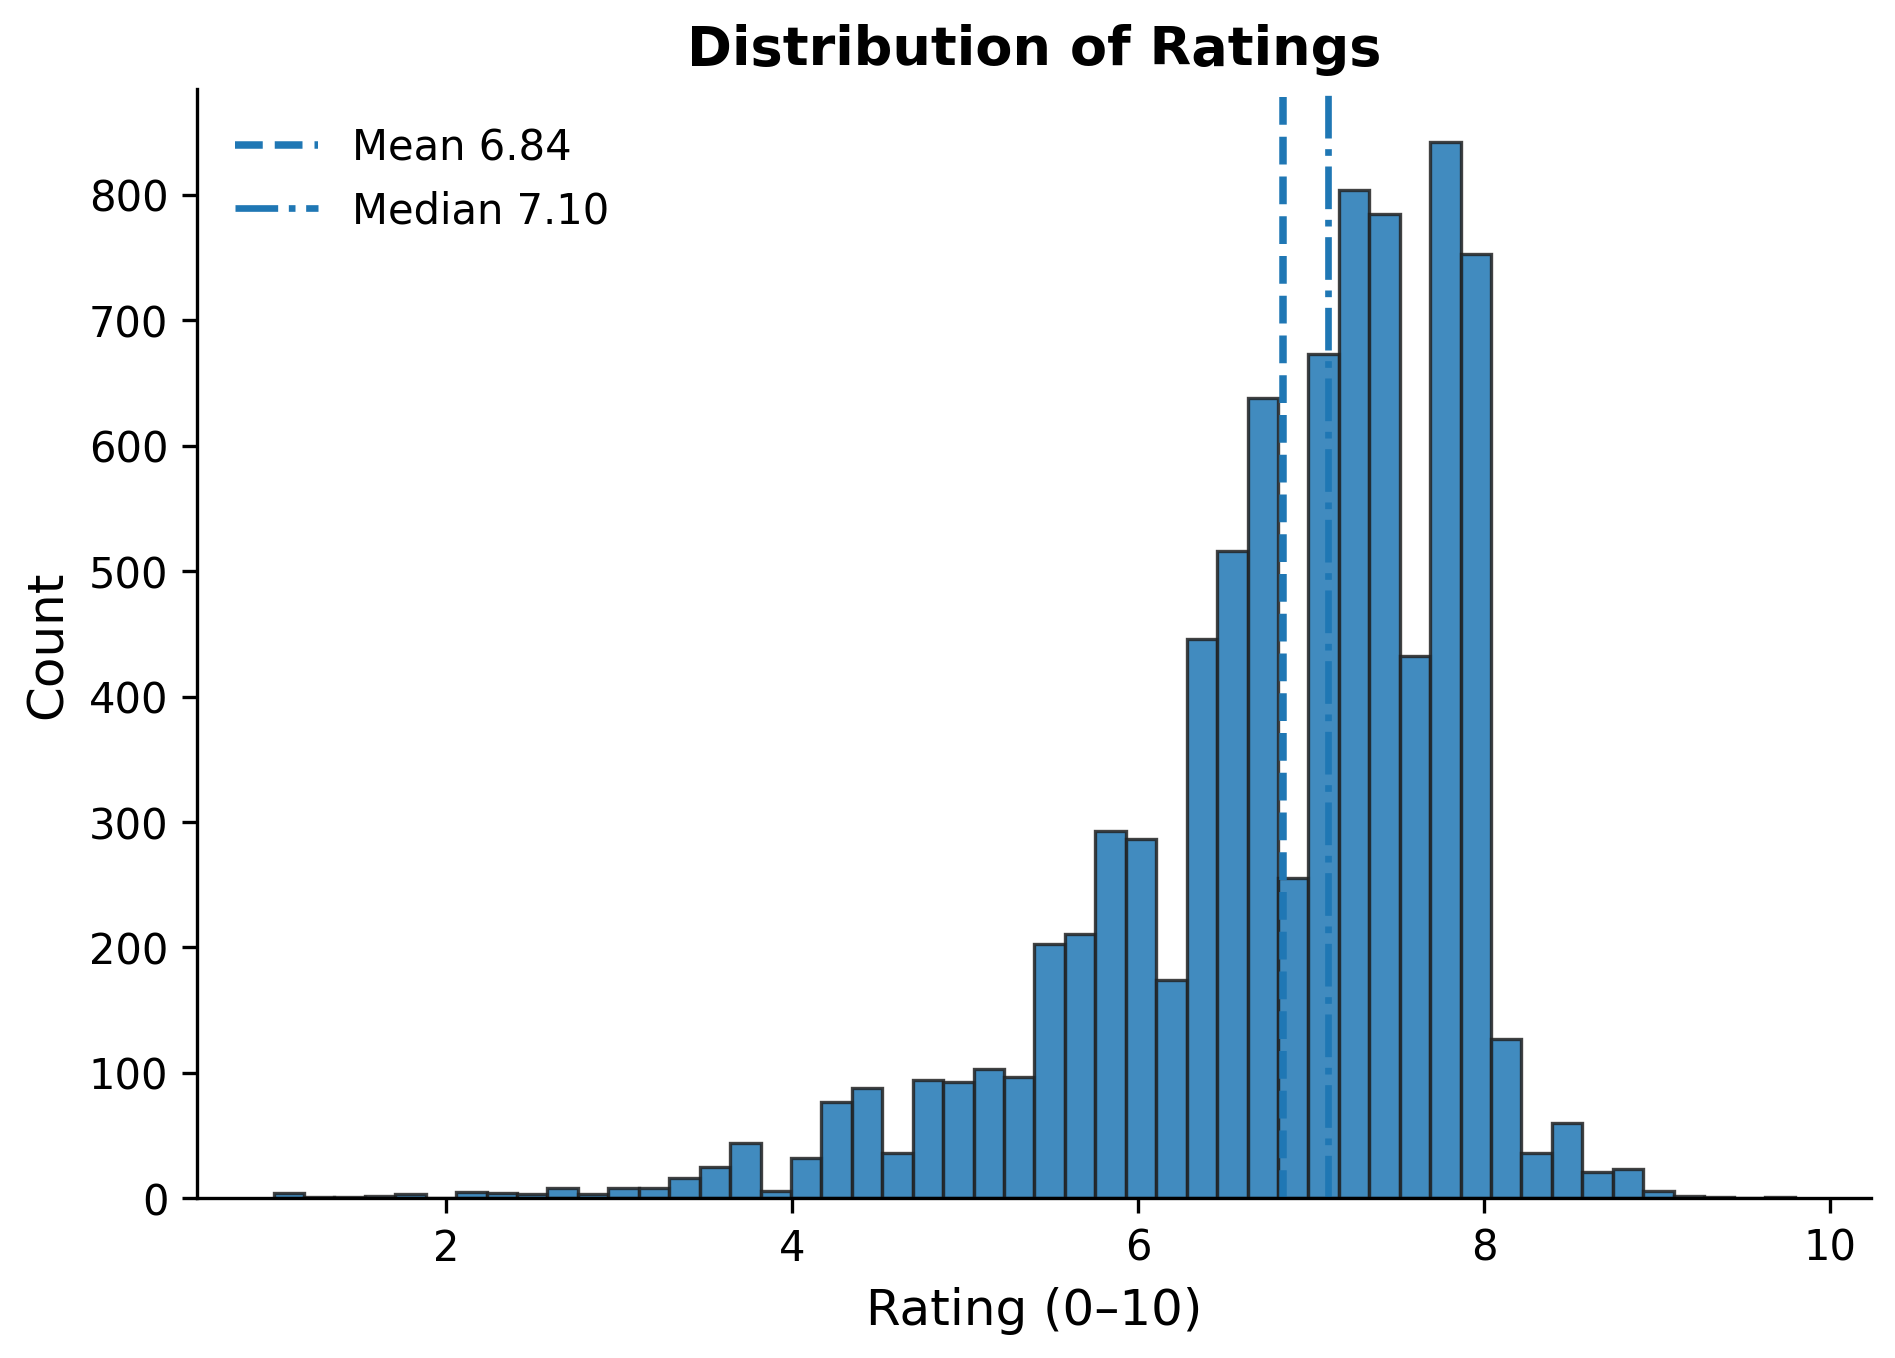
Mean ≈ 6.84, median ≈ 7.10; most ratings cluster around 7–8.5.

**Average rating by genre**  
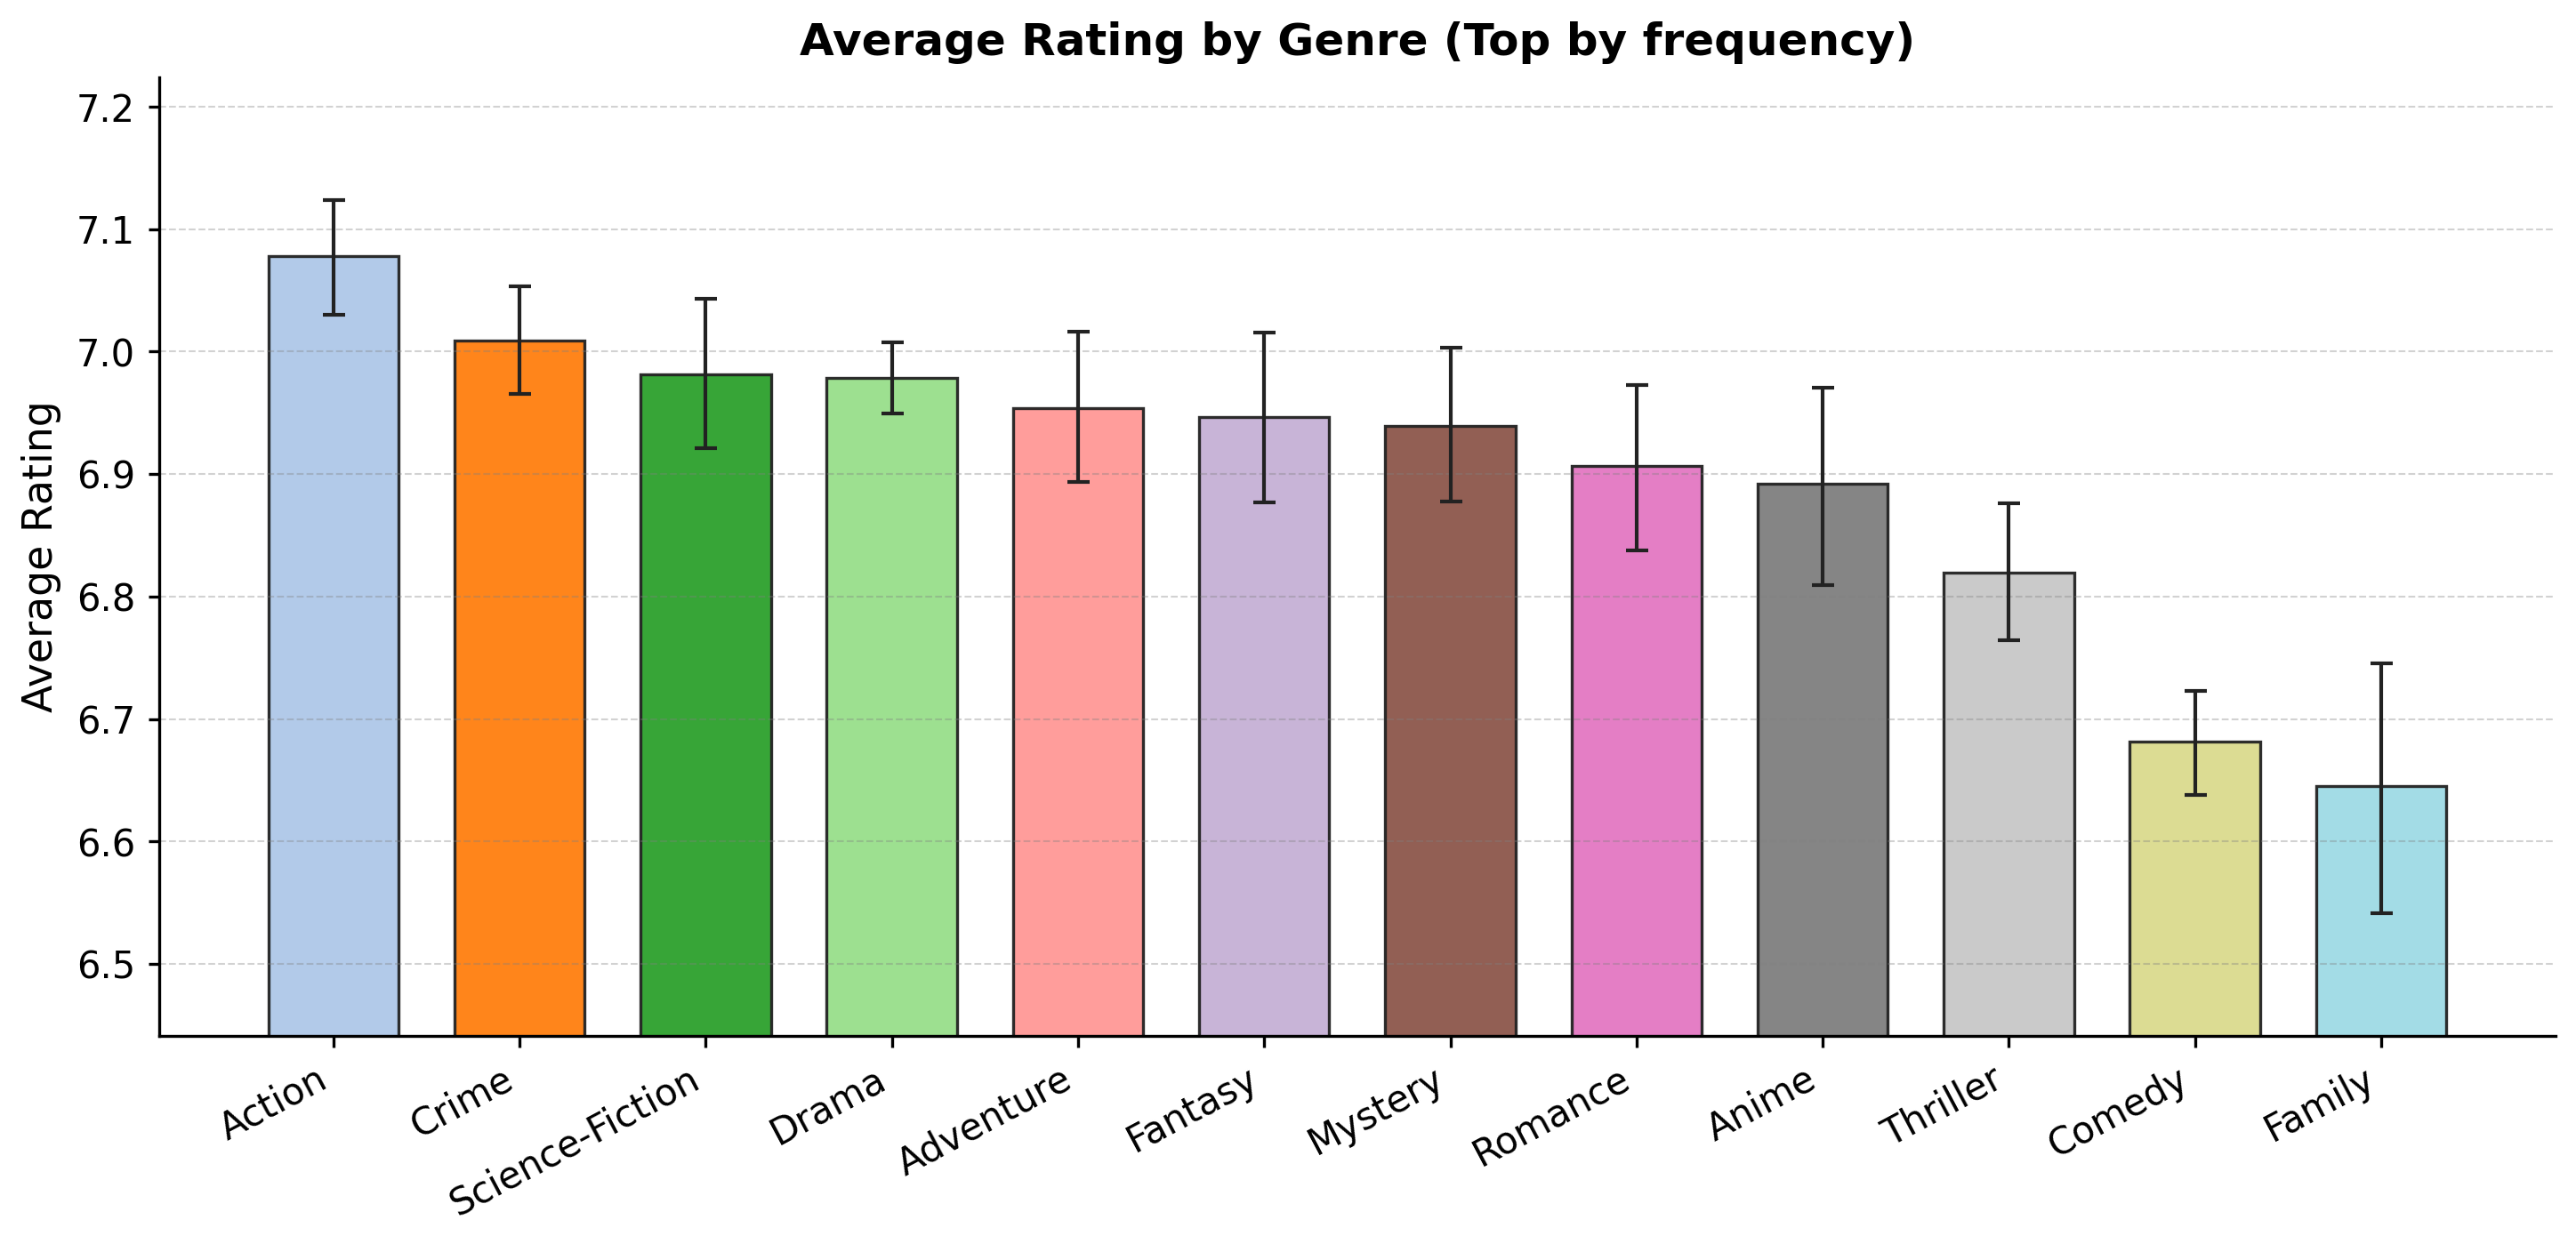
Top 12 genres by frequency; uses original `Genres` as provided.

**Ratings by status**  
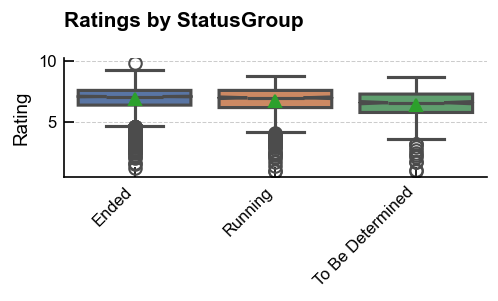
Boxplots for `Ended`, `Running`, `To Be Determined`; tests **H1**.

**Years active vs rating**  
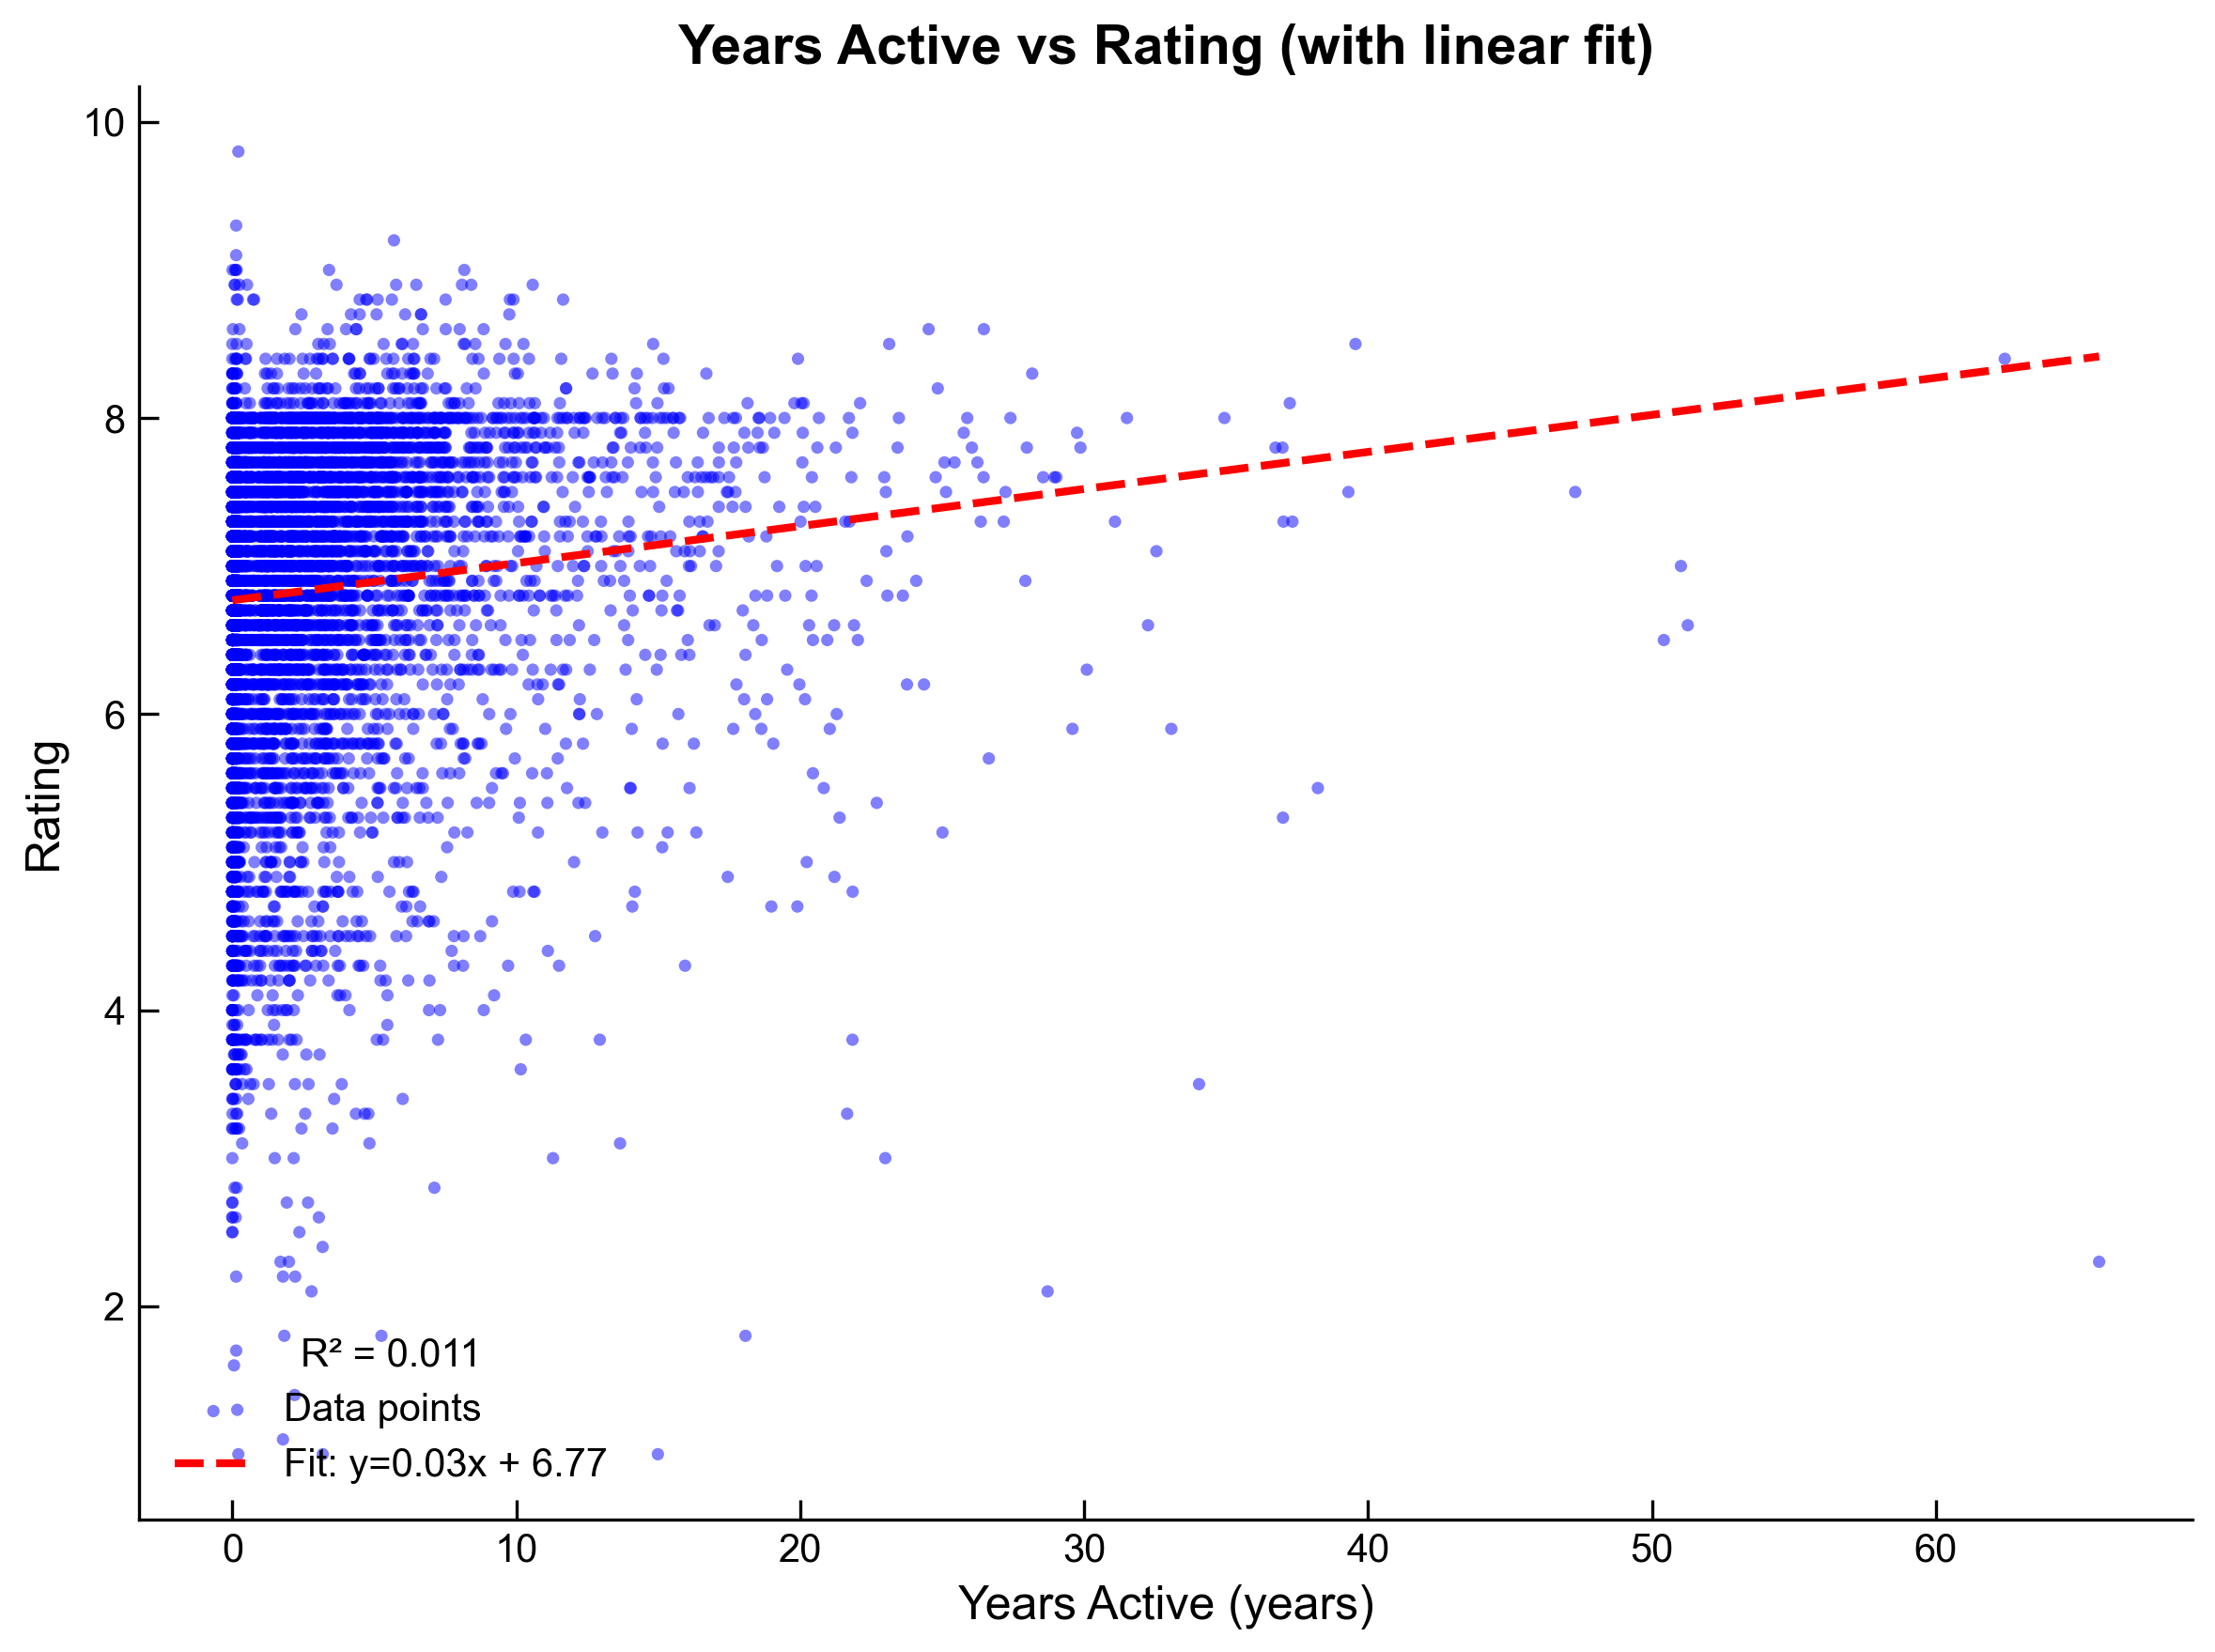
Linear fit: $y \approx 0.03x + 6.77$, $R^2 \approx 0.011$; relates to **H3**.

**Average rating by network (top 10)**  
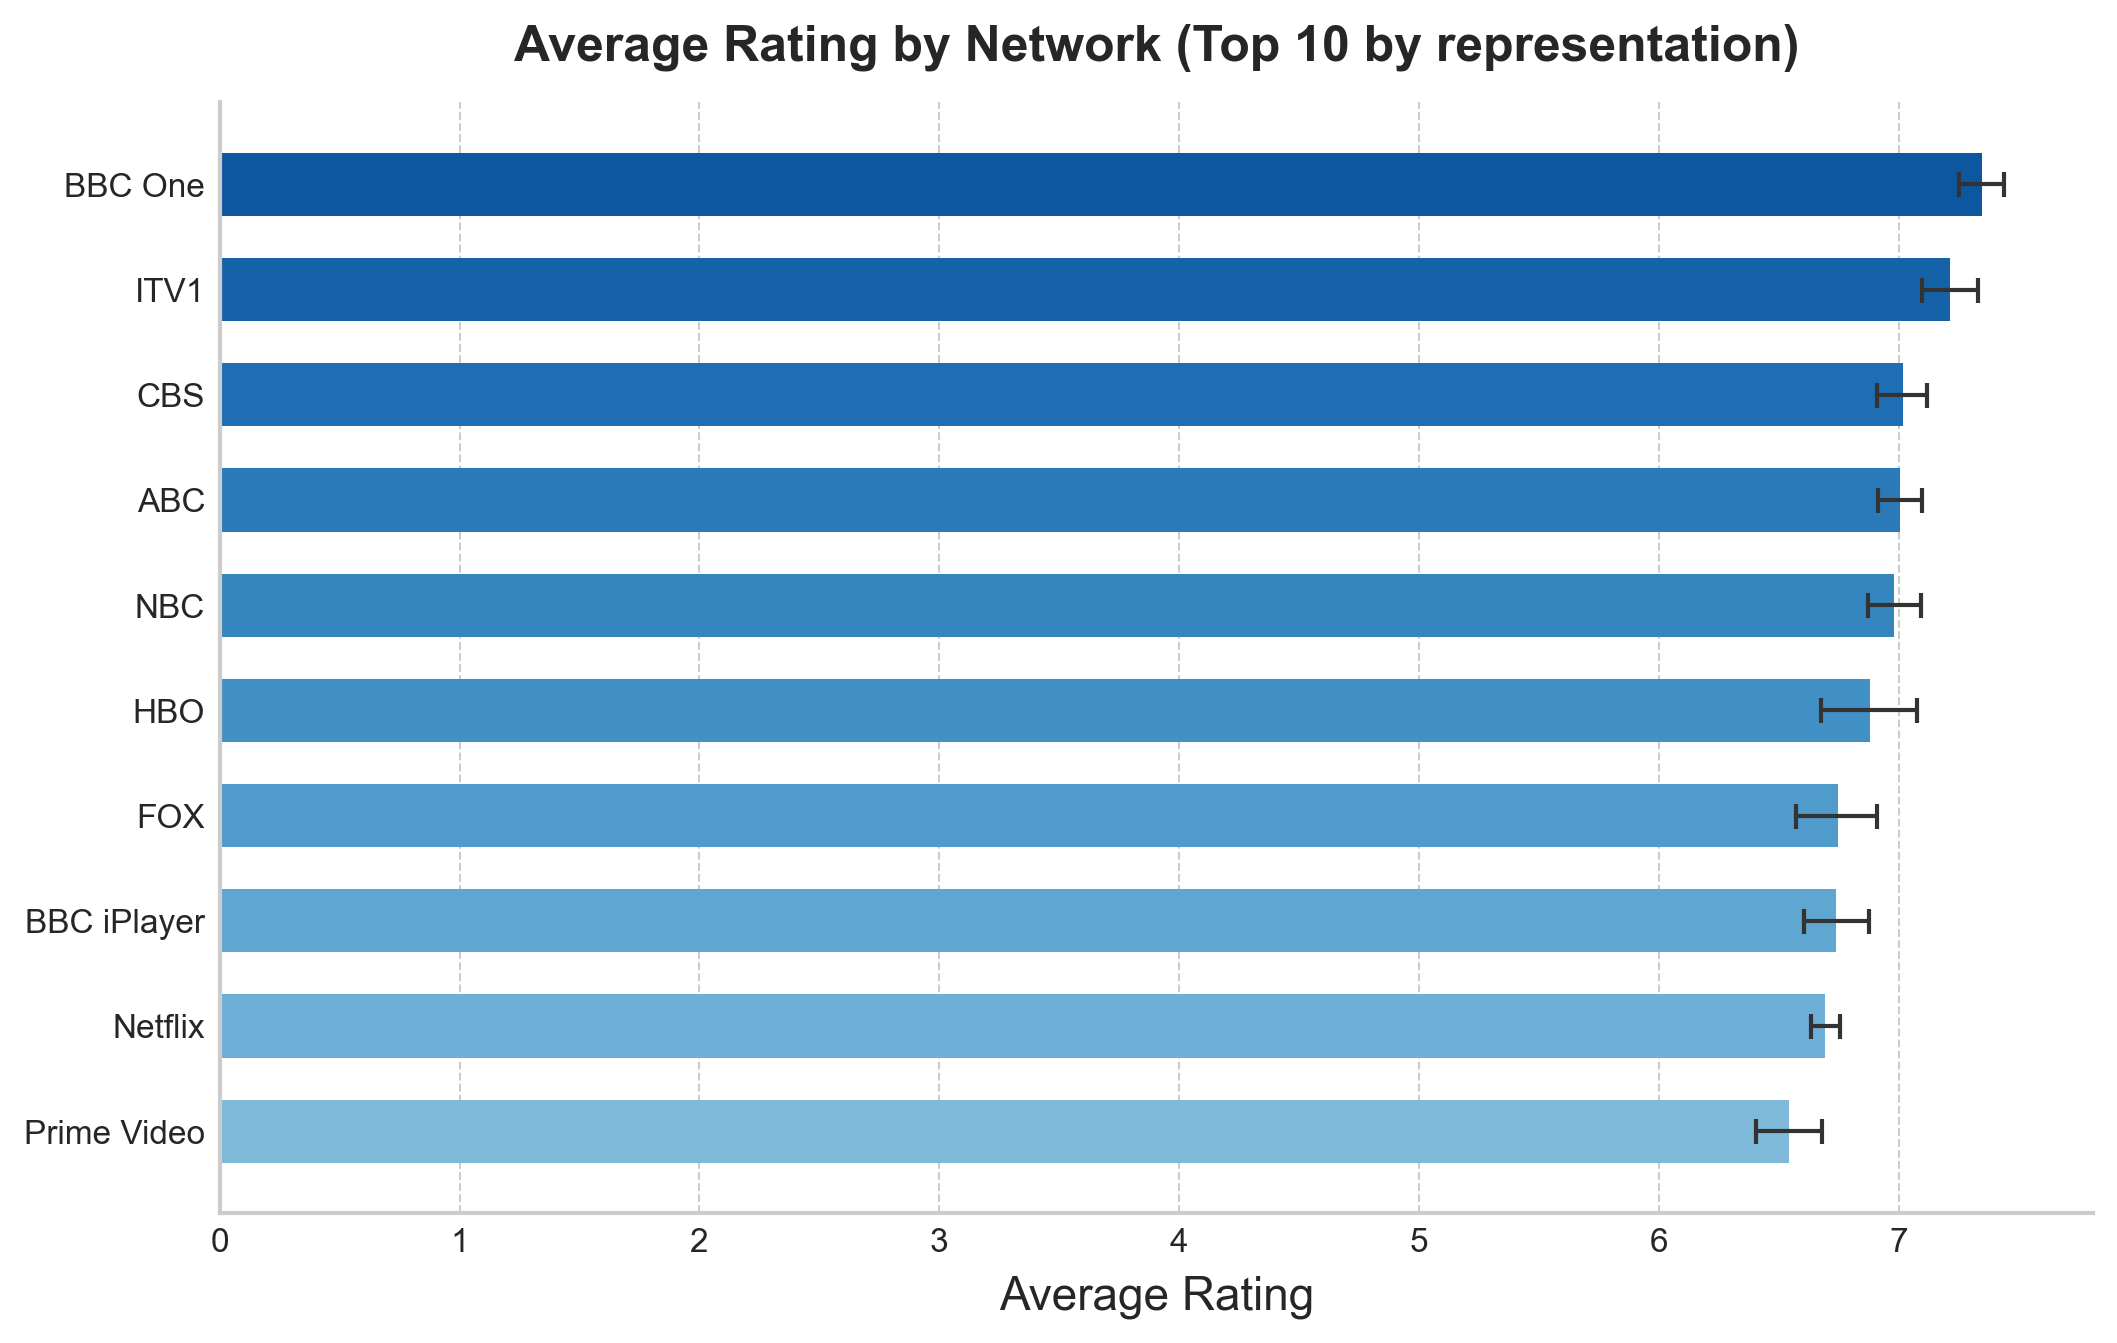
**Platform type share**  
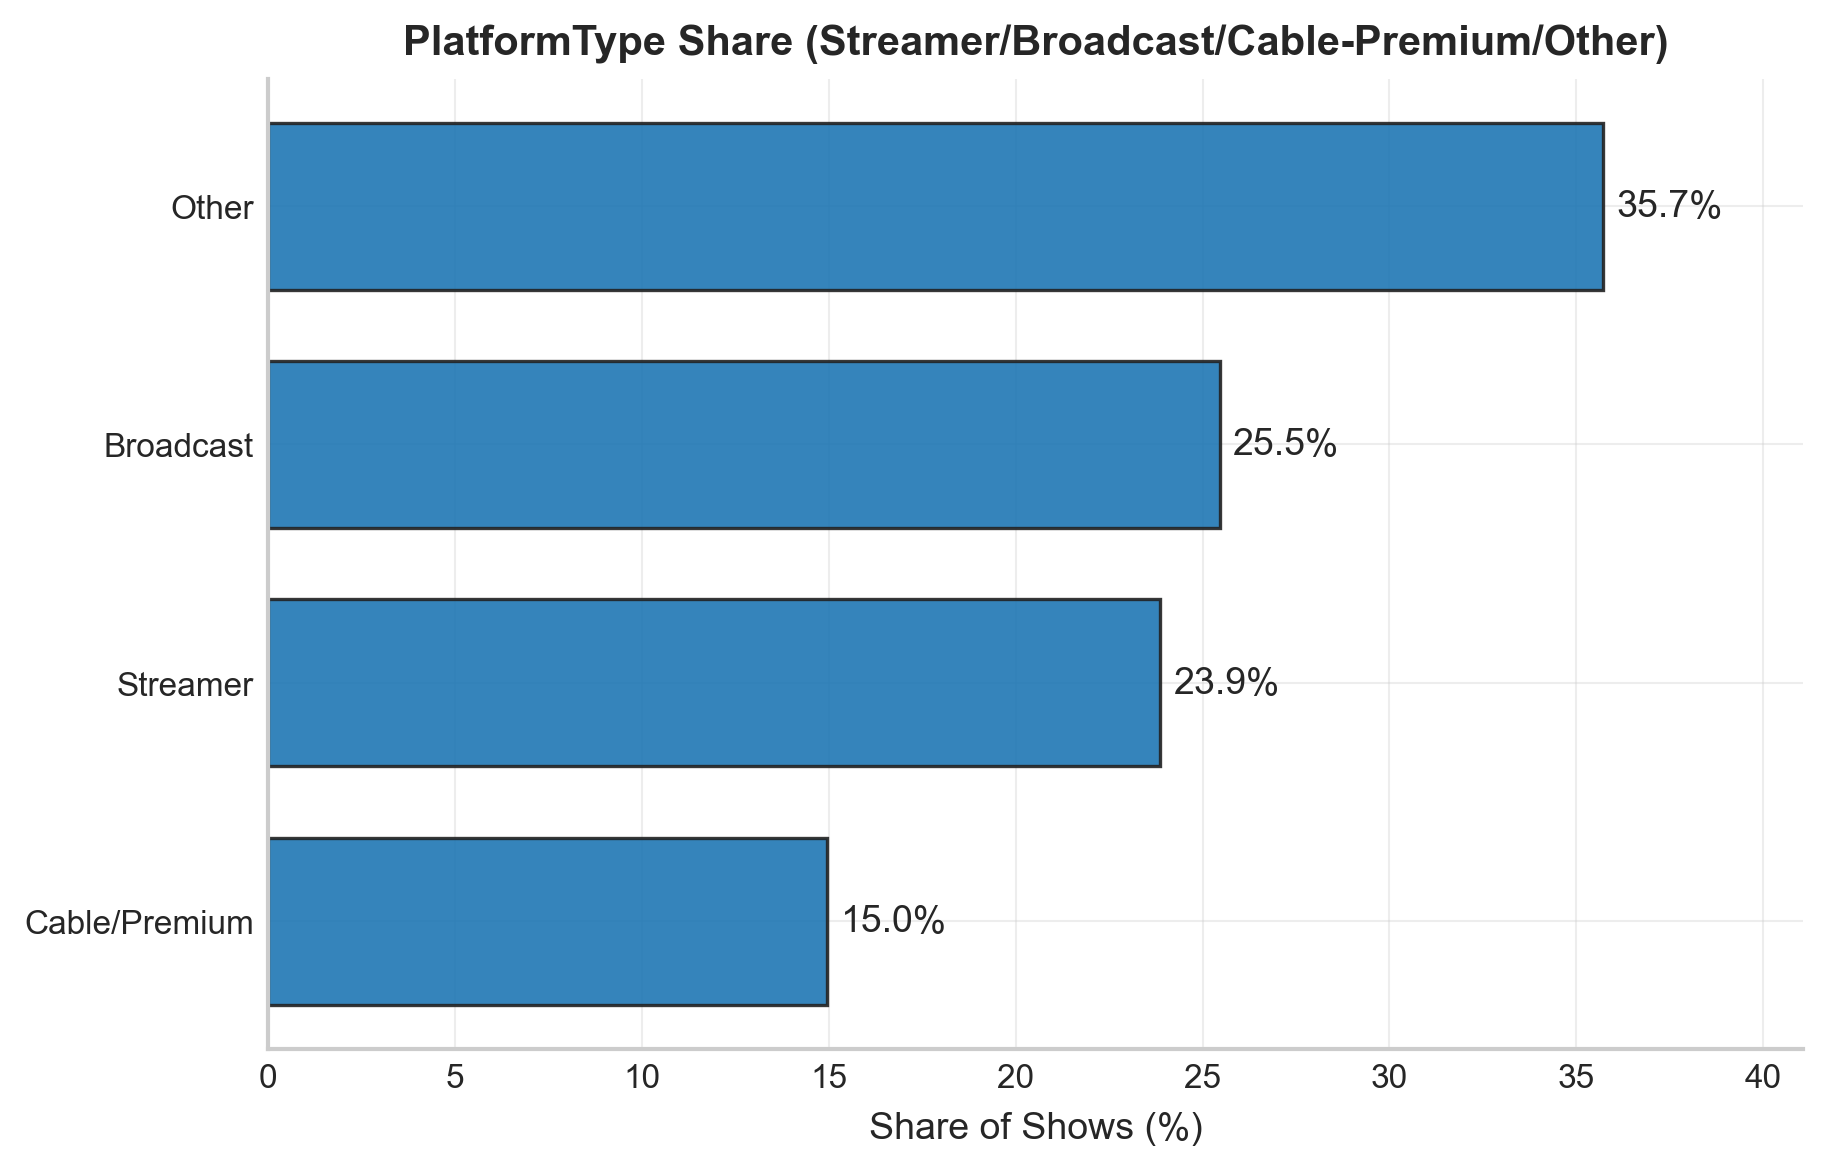
`Other` = 35.7%, `Broadcast` = 25.5%, `Streamer` = 23.9%, `Cable/Premium` = 15.0%.

**New shows over time**  
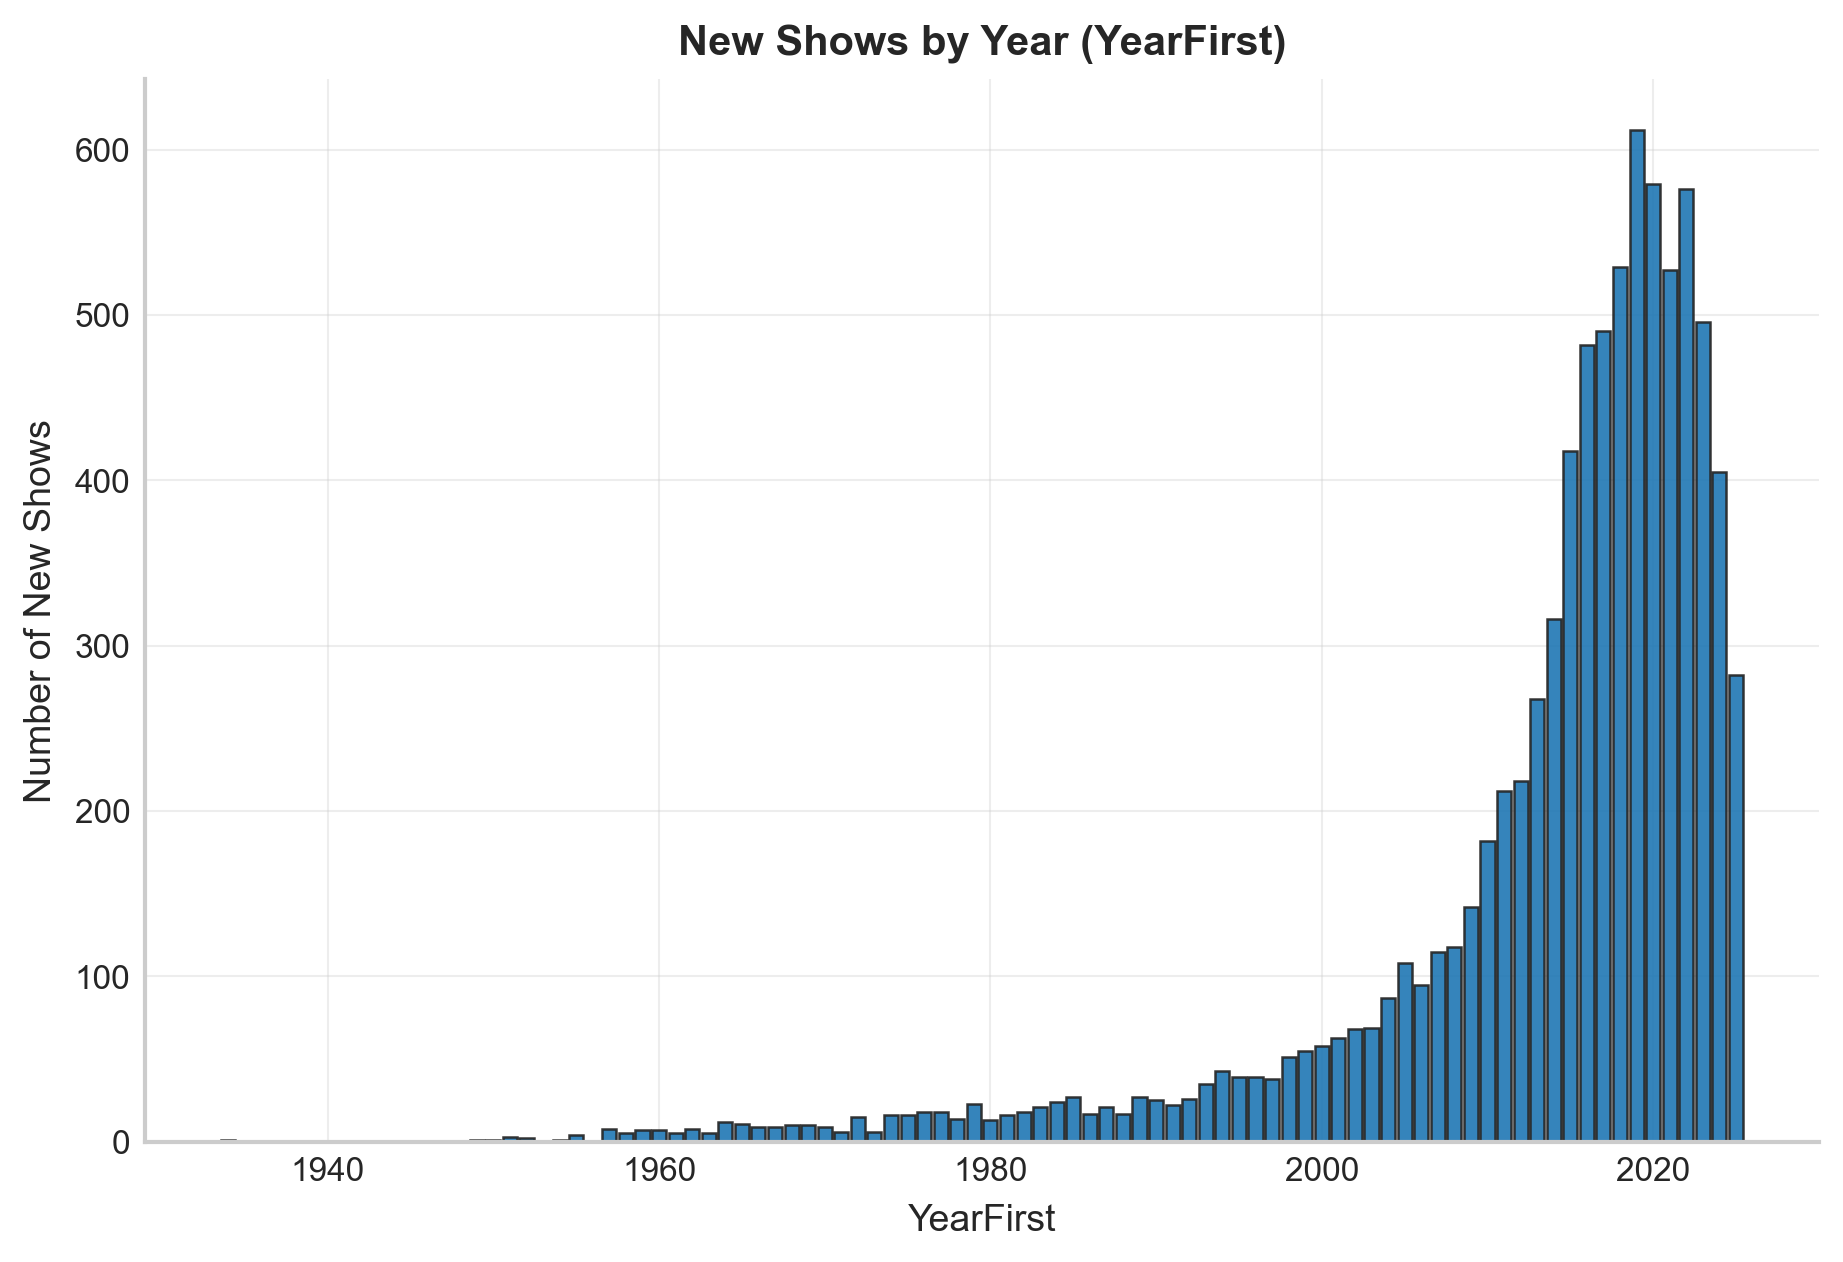
Growth after 2010, peak around 2018–2020.

### Results & Interpretation
**H1 (Status Premium)**  
The median/upper quartile of _“completed”_ shows is higher than that of _“currently airing”_ or _“pending”_ shows.  Possible mechanisms: narrative closure; selection bias (weaker shows tend to end early).

**H2 (Platform Effect)**  
Ratings vary by _platform type_; platform share and brand-level averages suggest that the distribution model influences rating profiles.

**H3 (Longevity — the opposite of pre-registration resistance)**  
The slightly positive slope (_R² ≈ 0.011_) suggests survivorship bias — long-lived shows are those that consistently achieve recognition.

**H4 (Genre Pattern)**  
Genre means vary within a narrow range (approximately 7–8).  The intention is to use native labels for descriptive comparison.

### What to watch first?
If you don't like cliffhangers, the top-rated "completed" series are your safest bet. If you value brand consistency, the top networks in the **Network Average Ratings** charts tend to be more trustworthy.

### Limitations
- **No external enrichment**: Only 8 relevant fields.
- **Rule-based mapping**: `PlatformType` is heuristic; mixed types exist.
- **FranchiseLike heuristic**: Weak proxy for IP.
- **Single metric score**: Multiple factors are compressed; group means are indicative, not causal.

### Reproducibility & File Outputs
- Run the scraping cell to generate `YangHong2255396.csv` with 200 titles.
- Add plotting cells to produce the figures referenced above and save them under `figures/`.

### Conclusions
1) Completed series exhibit a modest status premium;
2) Platform type and network are associated with viewership profiles;
3) Series longevity exhibits a slight positive correlation consistent with a survivorship bias;
4) There are differences across series types, but the range of differences is small.